<a href="https://colab.research.google.com/github/zaibshahzadi/ML-Internship/blob/main/Mall_Customers_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [113]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [114]:
df = pd.read_excel("Mall Customers.xlsx")

In [115]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [117]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Education,0
Marital Status,0
Annual Income (k$),0
Spending Score (1-100),0


In [118]:
le = LabelEncoder()

text_columns = ["Gender","Education","Marital Status"]

for col in text_columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [119]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,1,19,3,1,15,39
1,2,1,21,2,2,15,81
2,3,0,20,2,1,16,6
3,4,0,23,3,3,16,77
4,5,0,31,5,1,17,40


In [120]:
X = df.drop("CustomerID",axis=1)

In [121]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [122]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

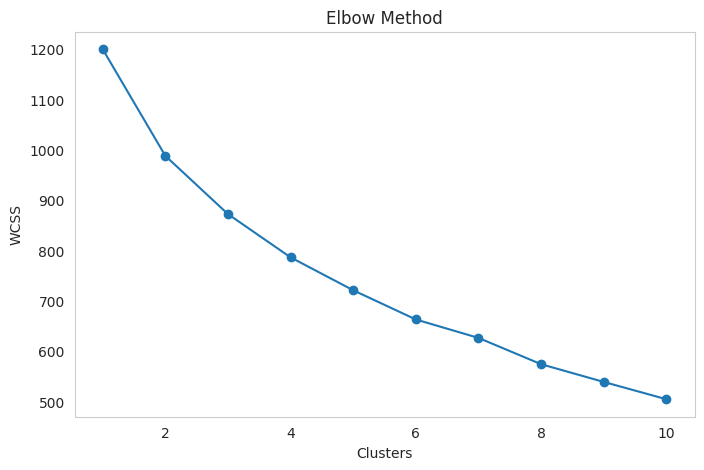

In [123]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid()

plt.show()

In [124]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [125]:
df["Cluster"] = clusters

In [126]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,3,1,15,39,0
1,2,1,21,2,2,15,81,0
2,3,0,20,2,1,16,6,2
3,4,0,23,3,3,16,77,3
4,5,0,31,5,1,17,40,2


In [127]:
df["Cluster"].value_counts()

,count
Cluster,
2,68
1,47
3,44
0,41


In [128]:
score = silhouette_score(
    X_scaled,
    clusters
)

print(score)

0.18010192866318542


In [129]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [130]:
centroids = pca.transform(kmeans.cluster_centers_)

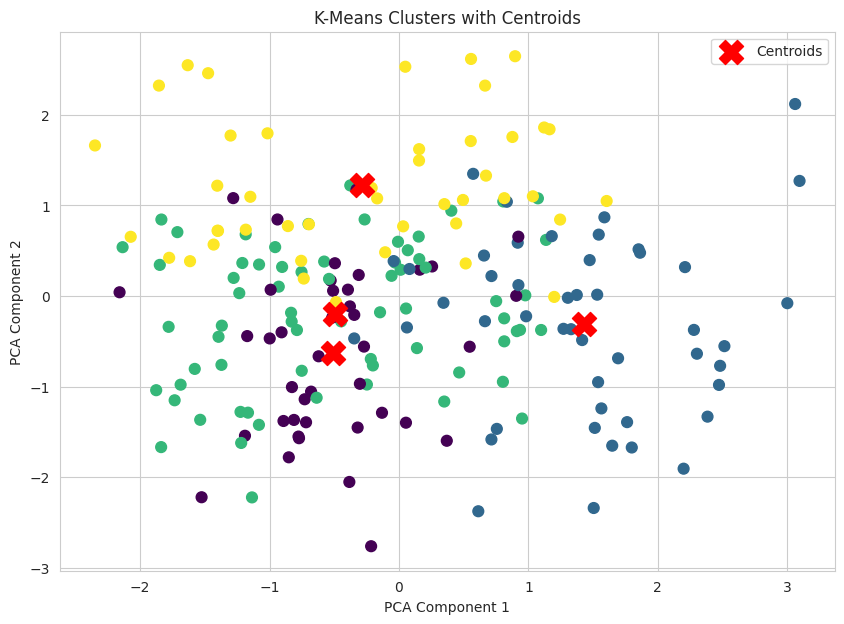

In [131]:
plt.figure(figsize=(10,7))

# Customers

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=60
)

# Centroids

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    color="red",
    marker="X",
    s=300,
    label="Centroids"
)

plt.title("K-Means Clusters with Centroids")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.legend()

plt.grid(True)

plt.show()

In [132]:
print(kmeans.cluster_centers_)

[[ 1.12815215 -0.74015963  0.22488189  0.06170852  0.04751628  0.81127593]
 [ 1.0424263   0.79714469  0.18130467 -0.13614281  0.07607898 -0.89487827]
 [-0.88640526 -0.16126397 -0.07227076 -0.71857192  0.04710557  0.07444605]
 [-0.79483447  0.08742488 -0.29152421  1.1984444  -0.19834223  0.08487805]]


In [133]:
df.groupby("Cluster").mean()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,,,
0,102.756098,1.000000,28.536585,3.439024,1.439024,61.804878,71.097561
1,105.638298,0.957447,49.957447,3.361702,1.297872,62.553191,27.148936
2,103.455882,0.000000,36.602941,2.911765,0.882353,61.794118,52.117647
3,88.340909,0.045455,40.068182,2.522727,2.250000,55.363636,52.386364


In [134]:
X = df.drop("Cluster",axis=1)

y = df["Cluster"]

In [135]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [136]:
param_grid = {

    "max_depth":[2,3,4,5,6],

    "criterion":["gini","entropy"]

}

In [137]:
grid = GridSearchCV(

    DecisionTreeClassifier(),

    param_grid,

    cv=5

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6]})

In [138]:
print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 5}


In [139]:
pred = grid.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.95
